In [ ]:
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import re

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Làm trên Kaggle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

Running on device: cuda


In [ ]:
# Cấu hình đường dẫn
TRAIN_DIR = '/kaggle/input/chess-positions/train' 
TEST_DIR = '/kaggle/input/chess-positions/test'
IMG_SIZE = 224 # Kích thước ảnh đầu vào cho mô hình
BATCH_SIZE = 1024
EPOCHS = 10
LEARNING_RATE = 0.001

# ÁNH XẠ LABE
# FEN map: chữ thường là quân đen, chữ hoa là quân trắng
# Chúng ta có 12 loại quân + 1 loại 'empty' 
pieces = ['p', 'r', 'n', 'b', 'q', 'k',  # Black
          'P', 'R', 'N', 'B', 'Q', 'K',  # White
          'empty']                       # Empty square

# Tạo dictionary để chuyển đổi qua lại giữa class ID và tên quân
class_to_idx = {p: i for i, p in enumerate(pieces)}
idx_to_class = {i: p for i, p in enumerate(pieces)}

print(f"Tổng số classes: {len(pieces)}")
print(class_to_idx)

Tổng số classes: 13
{'p': 0, 'r': 1, 'n': 2, 'b': 3, 'q': 4, 'k': 5, 'P': 6, 'R': 7, 'N': 8, 'B': 9, 'Q': 10, 'K': 11, 'empty': 12}


In [ ]:
def fen_to_labels(fen_filename):
    # 1. Lấy phần tên file
    basename = os.path.basename(fen_filename).split('.')[0]
    
    # 2. Chuẩn hóa FEN: 
    # dùng '-' thay cho '/' trong chuẩn FEN 
    board_fen = basename.replace('-', '/')
    
    rows = board_fen.split('/')
    labels = []
    
    for row in rows:
        for char in row:
            if char.isdigit():
                # Nếu là số (vd: 3), nghĩa là 3 ô trống liên tiếp
                num_empty = int(char)
                labels.extend([class_to_idx['empty']] * num_empty)
            else:
                # Nếu là ký tự quân cờ
                labels.append(class_to_idx[char])
                
    # Đảm bảo đủ 64 ô (phòng trường hợp FEN lỗi)
    if len(labels) != 64:
        raise ValueError(f"FEN lỗi, không đủ 64 ô: {basename}")
        
    return np.array(labels)

def split_board(image):
    h, w, c = image.shape
    
    # Tạo các mốc toạ độ chia đều (dạng float), sau đó làm tròn thành int
    x_steps = np.linspace(0, w, 9).astype(int)
    y_steps = np.linspace(0, h, 9).astype(int)
    
    squares = []
    for row in range(8):
        for col in range(8):
            # Lấy toạ độ bắt đầu và kết thúc từ mốc đã chia
            y1, y2 = y_steps[row], y_steps[row+1]
            x1, x2 = x_steps[col], x_steps[col+1]
            
            square = image[y1:y2, x1:x2]
            squares.append(square)
    return squares

In [ ]:
# CELL 4: DATASET 

class InMemoryChessDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.transform = transform
        self.data = []   # Chứa các ảnh ô cờ (numpy arrays)
        self.targets = [] # Chứa nhãn (int)

        print(f"Đang load {len(file_paths)} bàn cờ vào RAM. Vui lòng đợi...")
        
        # Duyệt qua từng file ảnh bàn cờ
        for img_path in tqdm(file_paths, desc="Loading & Processing"):
            try:
                # 1. Đọc ảnh
                image = cv2.imread(img_path)
                if image is None: continue
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                
                # 2. Lấy nhãn từ tên file
                labels = fen_to_labels(img_path)
                
                # 3. Cắt thành 64 ô 
                squares = split_board(image)
                
                # 4. Lưu vào list
                for i in range(64):
                    sq_resized = cv2.resize(squares[i], (50, 50))
                    
                    self.data.append(sq_resized)
                    self.targets.append(labels[i])
                    
            except Exception as e:
                print(f"Lỗi file {img_path}: {e}")
                continue
                
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Lấy dữ liệu trực tiếp từ RAM
        img = self.data[idx]
        label = self.targets[idx]
        
        # Áp dụng transform
        if self.transform:
            img = self.transform(img)
            
        return img, label

#1. Lấy danh sách file
all_files = glob.glob(os.path.join(TRAIN_DIR, "*.jpeg")) + glob.glob(os.path.join(TRAIN_DIR, "*.jpg"))

# 2. GIỚI HẠN SỐ LƯỢNG FILE 
MAX_FILES = 15000 
if len(all_files) > MAX_FILES:
    all_files = all_files[:MAX_FILES]
    print(f"Đã giới hạn dữ liệu xuống còn {MAX_FILES} bàn cờ để phù hợp với RAM.")

# 3. Chia file train/val
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

print("Khởi tạo Train Dataset (Load RAM)...")
# Transform cho train 
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(5), 
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_dataset = InMemoryChessDataset(train_files, transform=train_transform)

print("Khởi tạo Val Dataset (Load RAM)...")
# Transform cho val 
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_dataset = InMemoryChessDataset(val_files, transform=val_transform)

# 3. Tạo DataLoader với BATCH SIZE 
BATCH_SIZE = 1024 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Hoàn tất! Tổng số ô train: {len(train_dataset)}, Val: {len(val_dataset)}")

Đã giới hạn dữ liệu xuống còn 15000 bàn cờ để phù hợp với RAM.
Khởi tạo Train Dataset (Load RAM)...
Đang load 12000 bàn cờ vào RAM. Vui lòng đợi...


Loading & Processing: 100%|██████████| 12000/12000 [02:23<00:00, 83.51it/s] 


Khởi tạo Val Dataset (Load RAM)...
Đang load 3000 bàn cờ vào RAM. Vui lòng đợi...


Loading & Processing: 100%|██████████| 3000/3000 [00:55<00:00, 54.14it/s]

Hoàn tất! Tổng số ô train: 768000, Val: 192000


In [ ]:
class ChessCNN(nn.Module):
    def __init__(self, num_classes):
        super(ChessCNN, self).__init__()
        self.features = nn.Sequential(
            # Conv 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2), 
            
            # Conv 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2), 
            
            # Conv 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ChessCNN(num_classes=len(pieces)).to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

ChessCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': running_loss/total, 'acc': correct/total})
        
    return running_loss / len(loader), correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    return running_loss / len(loader), correct / total

best_acc = 0.0
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Lưu model tốt nhất
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "chess_model_best.pth")
        print("--> Saved Best Model")


Epoch 1/10


Training: 100%|██████████| 750/750 [04:18<00:00,  2.90it/s, loss=1.24e-5, acc=0.996]


Train Loss: 0.0127 | Train Acc: 0.9964
Val Loss: 0.0000 | Val Acc: 1.0000
--> Saved Best Model

Epoch 2/10


Training: 100%|██████████| 750/750 [04:19<00:00,  2.89it/s, loss=1.05e-6, acc=1]


Train Loss: 0.0011 | Train Acc: 0.9997
Val Loss: 0.0001 | Val Acc: 1.0000

Epoch 3/10


...

Train Loss: 0.0004 | Train Acc: 1.0000
Val Loss: 0.0000 | Val Acc: 1.0000

Epoch 9/10


Training: 100%|██████████| 750/750 [04:15<00:00,  2.94it/s, loss=1.1e-6, acc=1] 


Train Loss: 0.0011 | Train Acc: 0.9999
Val Loss: 0.0000 | Val Acc: 1.0000

Epoch 10/10


Training: 100%|██████████| 750/750 [04:15<00:00,  2.93it/s, loss=1.01e-6, acc=1]


Train Loss: 0.0010 | Train Acc: 0.9999
Val Loss: 0.0000 | Val Acc: 1.0000


Tìm thấy bàn cờ tại: X[108:600], Y[161:652]


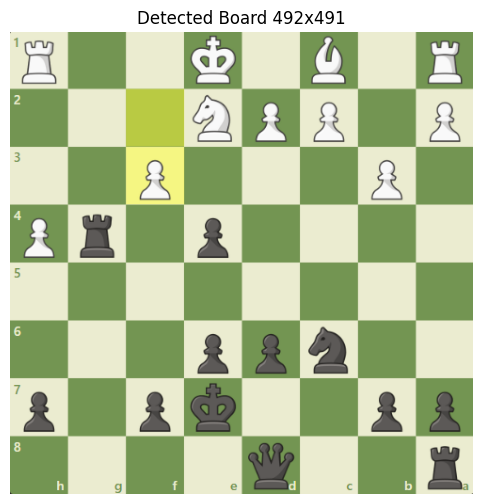

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def rle_1d(arr):
    if len(arr) == 0: return [], []
    # Dùng numpy để RLE nhanh hơn
    # Tìm các vị trí chuyển đổi giá trị
    diffs = np.diff(arr)
    # Các chỉ số mà tại đó giá trị thay đổi
    change_indices = np.where(diffs != 0)[0] + 1
    
    # Thêm chỉ số 0 và độ dài mảng vào
    indices = np.concatenate(([0], change_indices, [len(arr)]))
    
    # Tính độ dài các đoạn
    lengths = np.diff(indices)
    values = arr[indices[:-1]]
    
    return values, lengths

def find_k_equal_segments_1d(arr, k, eps=0, min_L=10):
    values, lengths = rle_1d(arr)
    if len(lengths) < k: return False, None, None, None, None

    # Quét qua các đoạn
    # Tìm chuỗi k đoạn có độ dài xấp xỉ nhau
    # Vì ảnh chụp màn hình có thể nhiễu, ta cho phép sai số eps cao hơn chút
    for i in range(len(lengths) - k + 1):
        window = lengths[i : i+k]
        
        # Kiểm tra độ dài tối thiểu
        if np.any(window < min_L): continue
            
        # Kiểm tra độ chênh lệch giữa max và min trong cửa sổ k đoạn
        # Nếu (max - min) <= eps thì coi như bằng nhau
        if (np.max(window) - np.min(window)) <= eps:
             # Tìm thấy!
            L_avg = int(np.mean(window))
            start_seg = i
            
            # Tính tọa độ pixel bắt đầu và kết thúc
            start_pixel = np.sum(lengths[:start_seg])
            end_pixel = start_pixel + np.sum(window)
            
            return True, L_avg, start_seg, start_pixel, end_pixel

    return False, None, None, None, None

def find_board_range(img_bin, axis, k=8, eps=5, min_L=20):
    H, W = img_bin.shape
    
    # Để chắc ăn, ta không chỉ quét 1 dòng mà quét nhiều dòng (step)
    # và lấy kết quả xuất hiện nhiều nhất (bền vững nhất)
    found_ranges = []
    
    if axis == 1: # Quét Ngang (tìm cột x)
        scan_range = range(0, H, 10) # Quét mỗi 10 dòng
        for r in scan_range:
            found, L, _, start, end = find_k_equal_segments_1d(img_bin[r], k, eps, min_L)
            if found: found_ranges.append((start, end))
    else:         # Quét Dọc (tìm hàng y)
        scan_range = range(0, W, 10) # Quét mỗi 10 cột
        for c in scan_range:
            found, L, _, start, end = find_k_equal_segments_1d(img_bin[:, c], k, eps, min_L)
            if found: found_ranges.append((start, end))
            
    if not found_ranges:
        return None
    
    # Lấy trung vị (median) của các tọa độ tìm được để loại bỏ nhiễu
    found_ranges = np.array(found_ranges)
    final_start = int(np.median(found_ranges[:, 0]))
    final_end = int(np.median(found_ranges[:, 1]))
    
    return final_start, final_end

# --- 2. XỬ LÝ ẢNH & CHẠY ---
img_path = "/kaggle/input/randomlichess/Untitled_4.png" #
full_img = cv2.imread(img_path)

if full_img is not None:

    gray = cv2.cvtColor(full_img, cv2.COLOR_BGR2GRAY)
    
    # Dùng Adaptive Threshold để tách ô cờ rõ nhất
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)

    # 1. Tìm trục ngang (X)
    x_range = find_board_range(thresh, axis=1, eps=10, min_L=30)
    
    # 2. Tìm trục dọc (Y)
    y_range = find_board_range(thresh, axis=0, eps=10, min_L=30)
    
    if x_range and y_range:
        x0, x1 = x_range
        y0, y1 = y_range
        
        print(f"Tìm thấy bàn cờ tại: X[{x0}:{x1}], Y[{y0}:{y1}]")
        
        # Cắt bàn cờ
        board_crop = full_img[y0:y1, x0:x1]
        
        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(board_crop, cv2.COLOR_BGR2RGB))
        plt.title(f"Detected Board {x1-x0}x{y1-y0}")
        plt.axis('off')
        plt.show()
    else:
        print("Không tìm thấy đủ 8 đoạn. Hãy thử chỉnh eps hoặc min_L.")
        # Hiển thị ảnh thresh để debug xem nó có ra sọc đen trắng không
        plt.imshow(thresh, cmap='gray')
        plt.title("Debug: Threshold Image")
        plt.show()
else:
    print("Không tìm thấy ảnh.")

In [8]:
# Cài đặt python-chess để xử lý logic cờ vua
!pip install python-chess

# Cài đặt Stockfish engine (trên môi trường Linux như Kaggle/Colab)
!apt-get install -y stockfish

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 56.0 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=cf2d159990052f90b518e9655f2334d752a1563e35e19e5a055643563bb464a6
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  polyglot xboard | scid
The following NEW packages will be installed:
  stockfish
0 upgraded, 1 newly installed, 0 to remove and 98 not upgraded.
Need to get 24.8 MB of archives.
After this operation, 47.4 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 stockfish amd64 14.1-1 [24.8 MB]
Fetched 24.8 MB in 1s (47.0 MB/s)  
Selecting previously unselected package stockfish.
(Reading database ... 129073 files and dir

In [30]:
model.eval()

ChessCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout

Dự đoán FEN: R2K1B1R/3NPP1P/2P3P1/Pr1p4/8/3ppn2/p1pk2pp/4q2r


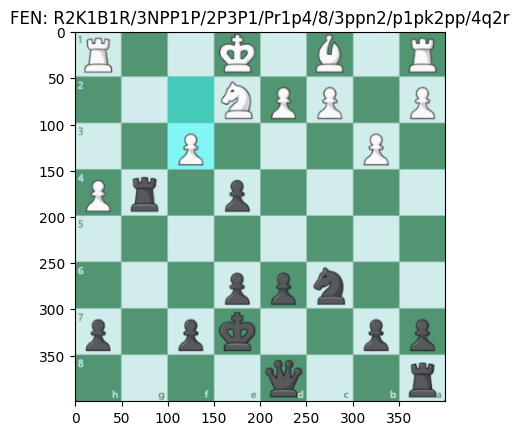

In [ ]:

def preprocess_square(square_img):
    # 1. Resize về 50x50 
    square_img = cv2.resize(square_img, (50, 50))

    # 2. Chuyển BGR -> RGB
    square_img = cv2.cvtColor(square_img, cv2.COLOR_BGR2RGB)

    tensor_img = val_transform(square_img)

    # 3. Thêm batch dimension (Model cần input 
    tensor_img = tensor_img.unsqueeze(0)

    return tensor_img.to(device)
def predict_full_board(model, board_img):
    """
    Dự đoán FEN từ ảnh bàn cờ đã crop (board_img)
    """
    model.eval() # Quan trọng: Chuyển sang chế độ đánh giá
    squares = split_board(board_img) 
    predicted_fen_parts = []

    with torch.no_grad():
        for i, sq in enumerate(squares):
            # 1. Tiền xử lý (Sửa lỗi màu và chuẩn hóa)
            input_tensor = preprocess_square(sq)

            # 2. Dự đoán
            outputs = model(input_tensor)
            _, predicted = torch.max(outputs, 1)
            class_idx = predicted.item()
            piece_char = idx_to_class[class_idx] # Lấy ký tự (p, k, R, empty...)

            predicted_fen_parts.append(piece_char)

    # 3. Gom lại thành chuỗi FEN (8 hàng, mỗi hàng 8 ô)

    fen_rows = []
    for row in range(8):
        row_pieces = predicted_fen_parts[row*8 : (row+1)*8]
        fen_row = ""
        empty_count = 0
        for p in row_pieces:
            if p == 'empty':
                empty_count += 1
            else:
                if empty_count > 0:
                    fen_row += str(empty_count)
                    empty_count = 0
                fen_row += p
        if empty_count > 0:
            fen_row += str(empty_count)
        fen_rows.append(fen_row)

    return "/".join(fen_rows)

# CHẠY THỬ
if 'board_crop' in locals() and board_crop is not None:
    fen_result = predict_full_board(model, board_crop)
    print("Dự đoán FEN:", fen_result)
    plt.imshow(cv2.resize(board_crop, (400, 400)))
    plt.title(f"FEN: {fen_result}")
    plt.show()

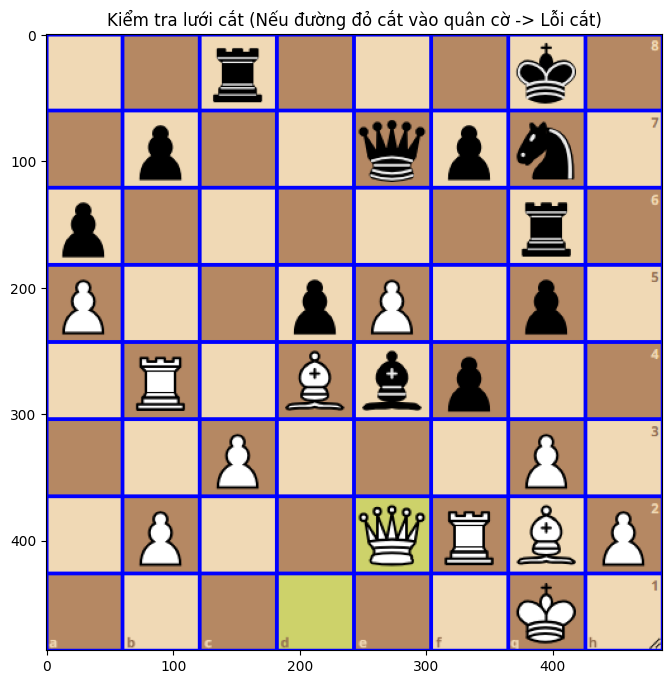

In [18]:
def visualize_grid(image):
    h, w = image.shape[:2]
    # Copy ảnh để vẽ
    debug_img = image.copy()
    
    # Tính toán toạ độ lưới (giống hàm split_board_precise)
    x_steps = np.linspace(0, w, 9).astype(int)
    y_steps = np.linspace(0, h, 9).astype(int)
    
    # Vẽ đường dọc
    for x in x_steps:
        cv2.line(debug_img, (x, 0), (x, h), (255, 0, 0), 2) # Màu đỏ
        
    # Vẽ đường ngang
    for y in y_steps:
        cv2.line(debug_img, (0, y), (w, y), (255, 0, 0), 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    plt.title("Kiểm tra lưới cắt (Nếu đường đỏ cắt vào quân cờ -> Lỗi cắt)")
    plt.show()

# --- CHẠY THỬ VỚI ẢNH CỦA BẠN ---
# board_crop là ảnh bàn cờ bạn đã crop được ở bước trước
if 'board_crop' in locals() and board_crop is not None:
    visualize_grid(board_crop)